In [6]:
from IPython.display import display
from vnstock_data import Quote, Trading, Finance, Listing, Company, CommodityPrice, Macro

Version Vnii 0.1.5 is available (subscription package). Please update using: `pip install --upgrade --extra-index-url https://vnstocks.com/api/simple vnii`.
Release history: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban
Current version: 0.1.2

✅ Authentication successful: Tung Pham
✅ Authentication successful: Tung Pham
✅ Authentication successful: Tung Pham


In [29]:
print("=== Quote.history ===")
q = Quote(source="vci", symbol="HPG", random_agent=False, show_log=False)
df_hist = q.history(start="2020-02-01", end="2025-04-18", interval="1D")
display(df_hist.head())

=== Quote.history ===


,time,open,high,low,close,volume
0,2020-02-03,8.03,8.55,7.83,8.47,12079180
1,2020-02-04,8.50,8.55,8.31,8.48,8086090
2,2020-02-05,8.57,8.62,8.34,8.43,6938550
3,2020-02-06,8.41,8.69,8.38,8.69,9214150
4,2020-02-07,8.69,8.72,8.34,8.40,8120240


The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


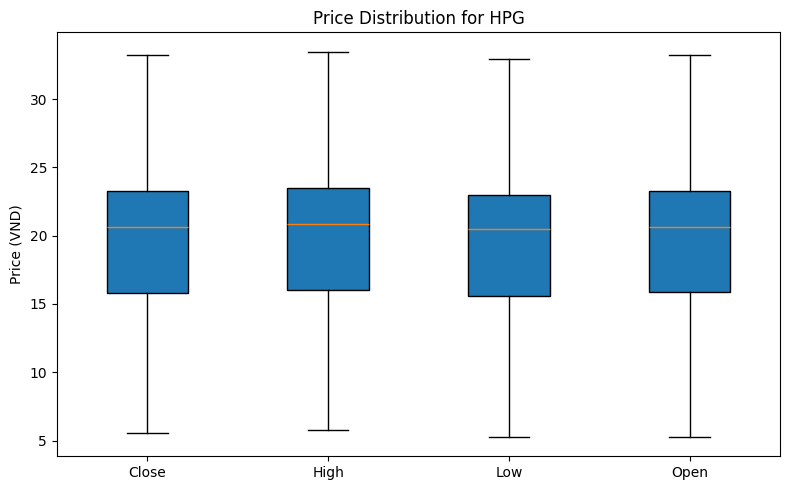

In [30]:
import matplotlib.pyplot as plt
data = [df_hist["close"],df_hist["high"],df_hist["low"],df_hist["open"]]
labels  = ["Close","High","Low","Open"]

plt.figure(figsize=(8,5))
plt.boxplot(data,labels=labels, patch_artist=True)

plt.title("Price Distribution for HPG")
plt.ylabel("Price (VND)")

plt.tight_layout()
plt.show()


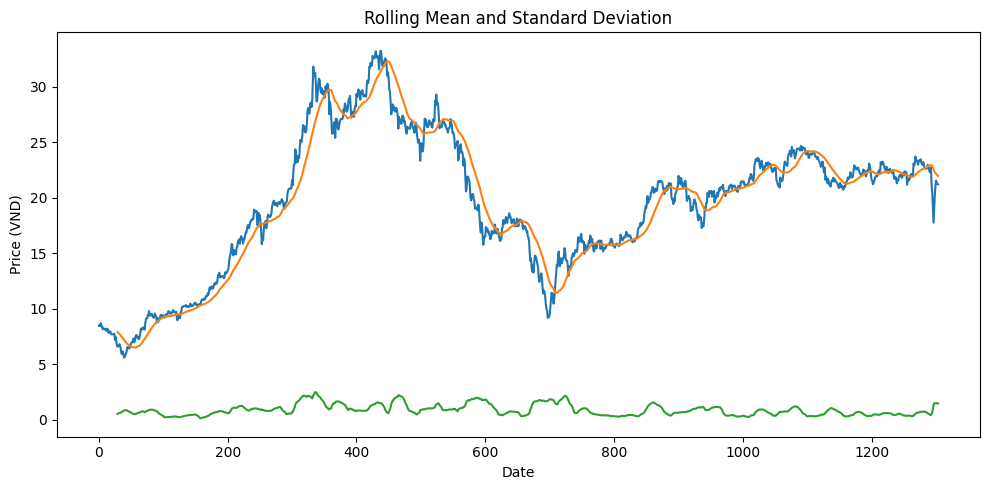

In [31]:
window = 30

rolling_mean = df_hist["close"].rolling(window=window).mean()
rolling_std = df_hist["close"].rolling(window=window).std()

plt.figure(figsize=(10,5))

plt.plot(df_hist.index, df_hist["close"],label = "Original")
plt.plot(df_hist.index, rolling_mean, label = "30-day Rolling Mean")
plt.plot(df_hist.index, rolling_std, label = "30-day Rolling Std")

plt.title("Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Price (VND)")

plt.tight_layout()
plt.show()

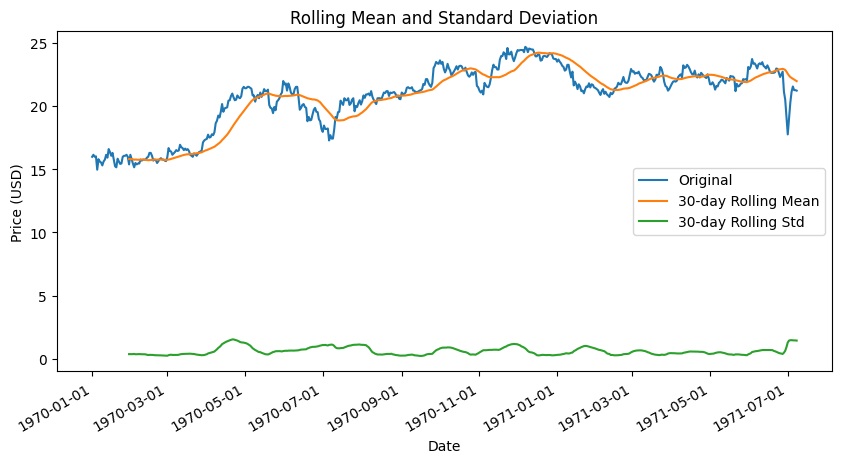

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_hist.index, df_hist["close"], label="Original")
ax.plot(df_hist.index, df_hist["close"].rolling(30).mean(), label="30-day Rolling Mean")
ax.plot(df_hist.index, df_hist["close"].rolling(30).std(), label="30-day Rolling Std")

ax.set_title("Rolling Mean and Standard Deviation")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")

# HIỂN THỊ NĂM TRÊN TRỤC X
ax.xaxis.set_major_locator(mdates.AutoDateLocator())        # mỗi tick là 1 năm
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # định dạng hiển thị năm

ax.legend()
fig.autofmt_xdate()   # xoay nhãn cho đẹp (optional)

plt.show()


In [12]:
df_hist.index.dtype

dtype('int64')

In [13]:
import pandas as pd
df_hist.index = pd.to_datetime(df_hist.index)

In [14]:
df_hist.index.dtype

dtype('<M8[ns]')

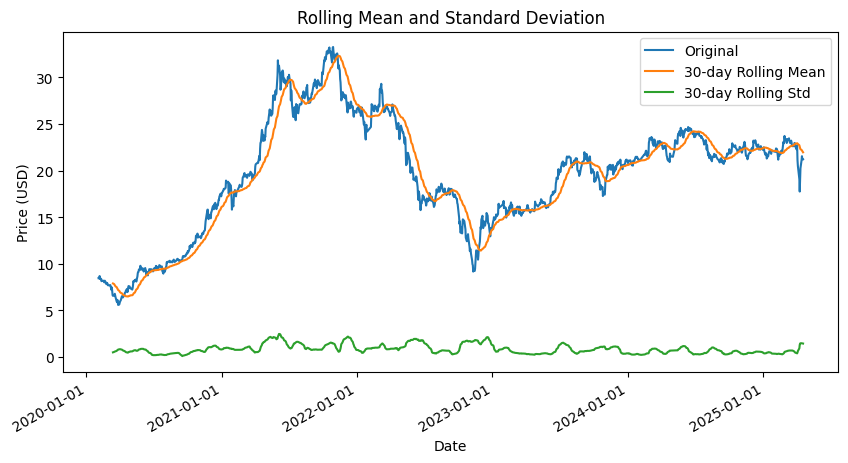

In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_hist["time"] = pd.to_datetime(df_hist["time"])
df_hist.set_index("time", inplace=True)


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_hist.index, df_hist["close"], label="Original")
ax.plot(df_hist.index, df_hist["close"].rolling(30).mean(), label="30-day Rolling Mean")
ax.plot(df_hist.index, df_hist["close"].rolling(30).std(), label="30-day Rolling Std")

ax.set_title("Rolling Mean and Standard Deviation")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")

# HIỂN THỊ NĂM TRÊN TRỤC X
ax.xaxis.set_major_locator(mdates.AutoDateLocator())        # mỗi tick là 1 năm
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # định dạng hiển thị năm

ax.legend()
fig.autofmt_xdate()   # xoay nhãn cho đẹp (optional)

plt.show()


In [16]:
df_hist.index.dtype

dtype('<M8[ns]')

In [22]:
df_hist.head()


,open,high,low,close,volume
time,,,,,
2023-02-01,16.82,17.16,15.91,15.98,51921554
2023-02-02,16.06,16.44,15.98,16.14,25396828
2023-02-03,16.25,16.33,15.91,15.98,20963608
2023-02-06,15.98,16.02,15.57,16.02,22290665
2023-02-07,16.02,16.06,14.92,14.96,43400365


In [6]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


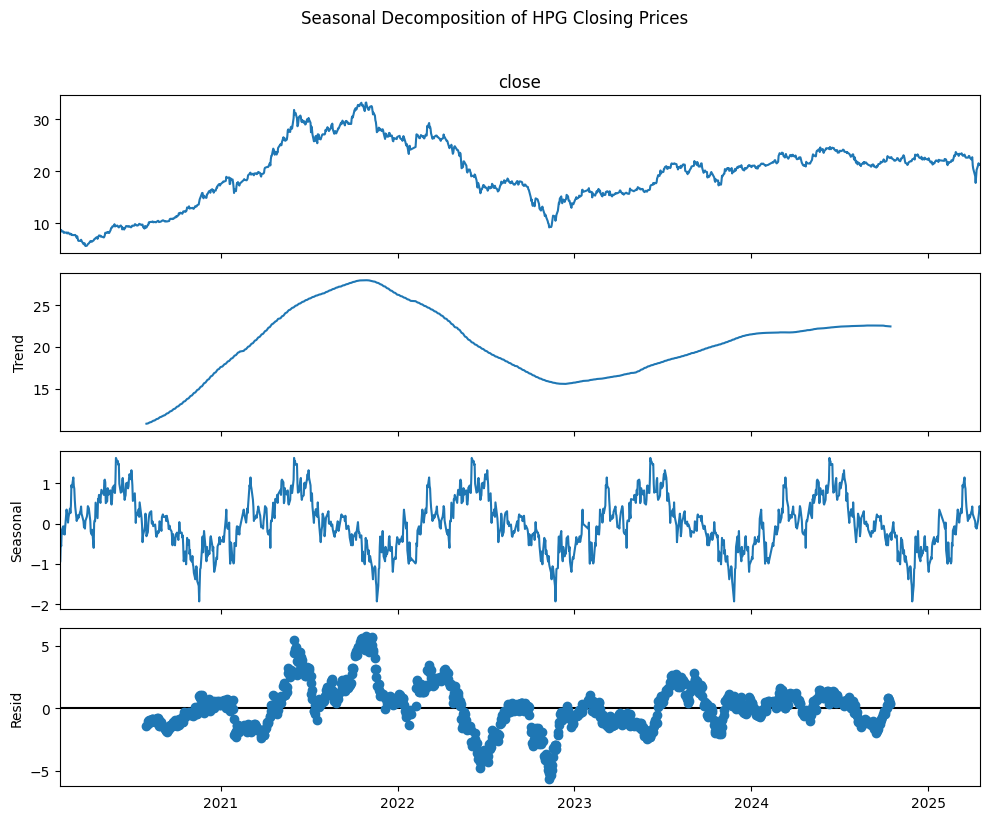

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df_hist["close"], model='additive', period=252)

fig = decomposition.plot()
fig.set_size_inches(10, 8)

plt.suptitle("Seasonal Decomposition of HPG Closing Prices", y=1.02)
plt.tight_layout()
plt.show()

In [34]:
seasonal = decomposition.seasonal

monthly_seasonal = (seasonal.groupby(seasonal.index.month).mean())

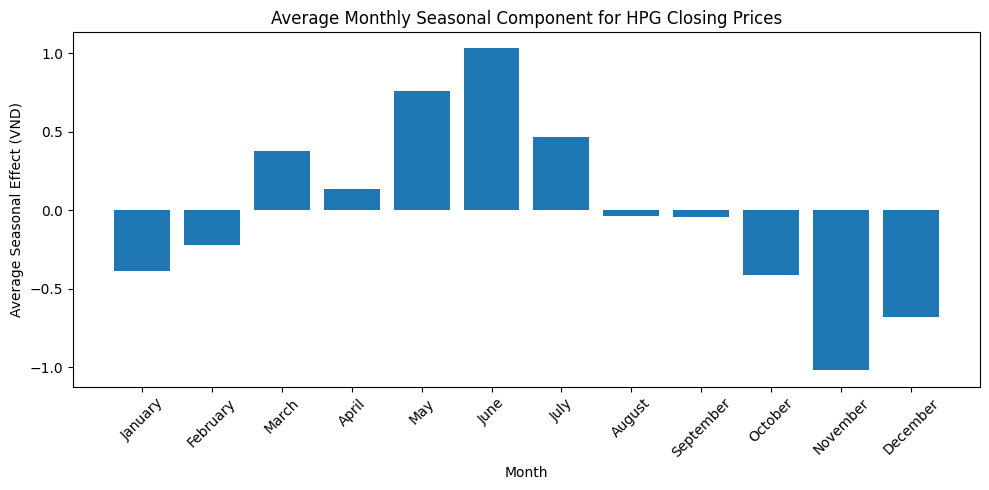

In [35]:
import calendar

months = [calendar.month_name[i] for i in range(1, 13)]
plt.figure(figsize=(10, 5))
plt.bar(months, monthly_seasonal)
plt.title("Average Monthly Seasonal Component for HPG Closing Prices")
plt.xlabel("Month")
plt.ylabel("Average Seasonal Effect (VND)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Bước 0: Lấy Data

In [7]:
print("=== Quote.history ===")
q = Quote(source="vci", symbol="HPG", random_agent=False, show_log=False)
df_hist = q.history(start="2020-02-01", end="2025-04-18", interval="1D")
display(df_hist.head())

=== Quote.history ===


,time,open,high,low,close,volume
0,2020-02-03,8.03,8.55,7.83,8.47,12079180
1,2020-02-04,8.50,8.55,8.31,8.48,8086090
2,2020-02-05,8.57,8.62,8.34,8.43,6938550
3,2020-02-06,8.41,8.69,8.38,8.69,9214150
4,2020-02-07,8.69,8.72,8.34,8.40,8120240


Bước 1: Data Preprocessing

In [8]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

class InputDataPreparation:
    """
    Chuẩn bị dữ liệu đầu vào theo đúng yêu cầu:
    - Period: 2017-2022
    - Split: 80% train, 10% gap, 10% test
    - Scaling: Min-Max [-1, 1]
    """
    def __init__(self, lookback=10):
        self.lookback = lookback
        self.scaler = MinMaxScaler(feature_range=(-1, 1))
        self.feature_columns = None
        self.train_dates = None
        self.gap_dates = None
        self.test_dates = None
    
    def load_data(self, filepath_or_dataframe, feature_columns=['Open', 'High', 'Low', 'Close', 'Volume']):
        """
        Load dữ liệu từ file hoặc DataFrame
        """
        if isinstance(filepath_or_dataframe, str):
            df = pd.read_csv(filepath_or_dataframe, index_col=0, parse_dates=True)
        else:
            df = filepath_or_dataframe.copy()
        
        # Lọc dữ liệu từ 2017-01-01 đến 2022-12-31
        #df = df.loc['2017-01-01':'2022-12-31']
        
        self.feature_columns = feature_columns
        print(f"✓ Loaded data: {len(df)} records from {df.index[0]} to {df.index[-1]}")
        
        return df
    
    def split_data(self, df):
        """
        Chia dữ liệu theo tỷ lệ 80-10-10
        """
        raw_data = df[self.feature_columns].values
        total_size = len(raw_data)
        
        if total_size < self.lookback + 10:
            raise ValueError(f"Not enough data: {total_size} records. Need at least {self.lookback + 10} records.")
        
        # Tính toán kích thước
        train_size = int(total_size * 0.8)
        gap_size = int(total_size * 0.1)
        test_size = total_size - train_size - gap_size
        
        if test_size < 10:
            raise ValueError(f"Test set too small: {test_size} samples. Increase data or reduce lookback period.")
        
        # Chia dữ liệu
        train_data_raw = raw_data[:train_size]
        gap_data_raw = raw_data[train_size:train_size + gap_size]
        test_data_raw = raw_data[train_size + gap_size:]
        
        # Lưu dates
        self.train_dates = df.index[:train_size]
        self.gap_dates = df.index[train_size:train_size + gap_size]
        self.test_dates = df.index[train_size + gap_size:]
        
        print(f"\n✓ Data split completed:")
        print(f"  Training: {train_size} samples (80%) - {self.train_dates[0]} to {self.train_dates[-1]}")
        print(f"  Gap:      {gap_size} samples (10%) - {self.gap_dates[0]} to {self.gap_dates[-1]}")
        print(f"  Test:     {test_size} samples (10%) - {self.test_dates[0]} to {self.test_dates[-1]}")
        
        return train_data_raw, gap_data_raw, test_data_raw
    
    def normalize_data(self, train_data, gap_data, test_data):
        """
        Normalize dữ liệu về [-1, 1] chỉ dựa trên training set
        """
        # Fit scaler chỉ trên training data
        self.scaler.fit(train_data)
        
        # Transform tất cả các tập
        train_scaled = self.scaler.transform(train_data)
        gap_scaled = self.scaler.transform(gap_data)
        test_scaled = self.scaler.transform(test_data)
        
        print(f"\n✓ Data normalized to range [-1, 1]")
        print(f"  Train range: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")
        print(f"  Test range:  [{test_scaled.min():.3f}, {test_scaled.max():.3f}]")
        
        return train_scaled, gap_scaled, test_scaled
    
    def create_sequences(self, data, target_column_idx=3):
        """
        Tạo sequences cho time series (lookback window)
        """
        X, y = [], []
        
        for i in range(len(data) - self.lookback):
            X.append(data[i:i + self.lookback])
            y.append(data[i + self.lookback, target_column_idx])
        
        return np.array(X), np.array(y)
    
    def prepare(self, filepath_or_dataframe):
        """
        Pipeline hoàn chỉnh cho Input Data
        """
        print("="*60)
        print("STEP 1: INPUT DATA PREPARATION")
        print("="*60)
        
        # Load data
        df = self.load_data(filepath_or_dataframe)
        
        # Split data
        train_raw, gap_raw, test_raw = self.split_data(df)
        
        # Normalize
        train_scaled, gap_scaled, test_scaled = self.normalize_data(train_raw, gap_raw, test_raw)
        
        # Create sequences
        X_train, y_train = self.create_sequences(train_scaled)
        X_test, y_test = self.create_sequences(test_scaled)
        
        print(f"\n✓ Sequences created:")
        print(f"  X_train shape: {X_train.shape} (samples, lookback, features)")
        print(f"  y_train shape: {y_train.shape}")
        print(f"  X_test shape:  {X_test.shape}")
        print(f"  y_test shape:  {y_test.shape}")
        
        return X_train, y_train, X_test, y_test
    
    def inverse_transform(self, predictions, target_column_idx=3):
        """
        Chuyển predictions về giá trị gốc
        """
        dummy = np.zeros((len(predictions), len(self.feature_columns)))
        dummy[:, target_column_idx] = predictions.flatten()
        inverse_scaled = self.scaler.inverse_transform(dummy)
        return inverse_scaled[:, target_column_idx]

Bước 2: Xây dựng base leaner

2.1.ARIMA Model

In [18]:
from statsmodels.tsa.arima.model import ARIMA

class ARIMABaseModel:
    """
    ARIMA model cho time series forecasting
    """
    def __init__(self, order=(2, 1, 2)):
        self.order = order
        self.model = None
        self.fitted_model = None
    
    def fit(self, X_train, y_train):
        """
        Train ARIMA model
        """
        print("  [ARIMA] Training...", end=" ")
        
        # ARIMA làm việc với 1D data
        train_data = y_train.flatten()
        
        try:
            self.model = ARIMA(train_data, order=self.order)
            self.fitted_model = self.model.fit()
            print("✓ Done")
        except Exception as e:
            print(f"✗ Error: {e}")
            # Fallback to simpler model
            self.model = ARIMA(train_data, order=(1, 1, 1))
            self.fitted_model = self.model.fit()
            print("  [ARIMA] Used fallback order (1,1,1)")
        
        return self
    
    def predict(self, X_test):
        """
        Predict using ARIMA
        """
        forecast = self.fitted_model.forecast(steps=len(X_test))
        return forecast.reshape(-1, 1)

2.2. Random Forest Model

In [29]:
from sklearn.ensemble import RandomForestRegressor

class RandomForestBaseModel:
    """
    Random Forest model cho time series forecasting
    """
    def __init__(self, n_estimators=100, max_depth=10, random_state=42):
        self.model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
            n_jobs=-1
        )
    
    def fit(self, X_train, y_train):
        """
        Train Random Forest
        """
        print("  [Random Forest] Training...", end=" ")
        
        # Reshape cho Random Forest (2D)
        X_train_rf = X_train.reshape(X_train.shape[0], -1)
        self.model.fit(X_train_rf, y_train.ravel())
        
        print("✓ Done")
        return self
    
    def predict(self, X_test):
        """
        Predict using Random Forest
        """
        X_test_rf = X_test.reshape(X_test.shape[0], -1)
        predictions = self.model.predict(X_test_rf)
        return predictions.ravel()

2.3. LSTM Model

In [40]:
import tensorflow as tf
from tensorflow import keras
from tensorflow .keras.models import Sequential
from tensorflow .keras.layers import LSTM, Dense, Dropout

class LSTMBaseModel:
    """
    LSTM model cho time series forecasting
    """
    def __init__(self):
        self.model = None
    
    def build_model(self, input_shape):
        """
        Xây dựng kiến trúc LSTM
        """
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(
            optimizer='adam',
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def fit(self, X_train, y_train, epochs=50, batch_size=32):
        """
        Train LSTM
        """
        print("  [LSTM] Training...", end=" ")
        
        input_shape = (X_train.shape[1], X_train.shape[2])
        self.model = self.build_model(input_shape)
        
        # Train với validation split
        self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            verbose=0
        )
        
        print("✓ Done")
        return self
    
    def predict(self, X_test):
        """
        Predict using LSTM
        """
        return self.model.predict(X_test, verbose=0).ravel()

In [20]:
%pip install --upgrade --quiet tensorflow-cpu

Note: you may need to restart the kernel to use updated packages.


2.4. GRU Model

In [12]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [39]:
from tensorflow.keras.layers import GRU

class GRUBaseModel:
    """
    GRU model cho time series forecasting
    """
    def __init__(self):
        self.model = None
    
    def build_model(self, input_shape):
        """
        Xây dựng kiến trúc GRU
        """
        model = Sequential([
            GRU(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            GRU(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(
            optimizer='adam',
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def fit(self, X_train, y_train, epochs=50, batch_size=32):
        """
        Train GRU
        """
        print("  [GRU] Training...", end=" ")
        
        input_shape = (X_train.shape[1], X_train.shape[2])
        self.model = self.build_model(input_shape)
        
        self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            verbose=0
        )
        
        print("✓ Done")
        return self
    
    def predict(self, X_test):
        """
        Predict using GRU
        """
        return self.model.predict(X_test, verbose=0).ravel()

2.5. Transformer Model

In [38]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

class TransformerBaseModel:
    """
    Transformer model cho time series forecasting
    """
    def __init__(self):
        self.model = None
    
    def build_model(self, input_shape, head_size=256, num_heads=4, ff_dim=4, num_transformer_blocks=2):
        """
        Xây dựng kiến trúc Transformer
        """
        inputs = keras.Input(shape=input_shape)
        x = inputs
        
        # Transformer blocks
        for _ in range(num_transformer_blocks):
            # Multi-head attention
            attention_output = MultiHeadAttention(
                key_dim=head_size,
                num_heads=num_heads,
                dropout=0.1
            )(x, x)
            attention_output = Dropout(0.1)(attention_output)
            x = LayerNormalization(epsilon=1e-6)(x + attention_output)
            
            # Feed-forward network
            ffn = Sequential([
                Dense(ff_dim, activation="relu"),
                Dropout(0.1),
                Dense(input_shape[1])
            ])
            ffn_output = ffn(x)
            x = LayerNormalization(epsilon=1e-6)(x + ffn_output)
        
        # Output layers
        x = GlobalAveragePooling1D()(x)
        x = Dense(32, activation="relu")(x)
        x = Dropout(0.1)(x)
        outputs = Dense(1)(x)
        
        model = keras.Model(inputs=inputs, outputs=outputs)
        model.compile(
            optimizer='adam',
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def fit(self, X_train, y_train, epochs=50, batch_size=32):
        """
        Train Transformer
        """
        print("  [Transformer] Training...", end=" ")
        
        input_shape = (X_train.shape[1], X_train.shape[2])
        self.model = self.build_model(input_shape)
        
        self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            verbose=0
        )
        
        print("✓ Done")
        return self
    
    def predict(self, X_test):
        """
        Predict using Transformer
        """
        return self.model.predict(X_test, verbose=0).ravel()

Bước 3: Meta-Learner

In [25]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 8.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 6.3 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [37]:

from xgboost import XGBRegressor

class MetaLearner:
    """
    XGBoost làm meta-learner để kết hợp predictions từ base learners
    """
    def __init__(self, n_estimators=200, max_depth=5, learning_rate=0.01):
        self.model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=42
        )
    
    def fit(self, meta_features, y_train):
        """
        Train meta-learner trên predictions của base learners
        """
        print("\n" + "="*60)
        print("STEP 3: LEVEL 1 - META-LEARNER (XGBoost)")
        print("="*60)
        print(f"  Meta-features shape: {meta_features.shape}")
        print("  Training XGBoost meta-learner...", end=" ")
        
        self.model.fit(meta_features, y_train.ravel())
        
        print("✓ Done")
        return self
    
    def predict(self, meta_features):
        """
        Predict sử dụng meta-learner
        """
        return self.model.predict(meta_features)
    
    def get_feature_importance(self):
        """
        Lấy feature importance để biết model nào đóng góp nhiều nhất
        """
        return self.model.feature_importances_

Bước 4: Agregated Forecast- Stacking Ensemble

In [35]:
from sklearn.model_selection import TimeSeriesSplit
class StackingEnsembleForecaster:
    """
    Stacking Ensemble hoàn chỉnh kết hợp tất cả các thành phần
    """
    def __init__(self, data_preprocessor):
        self.preprocessor = data_preprocessor
        
        # Level 0: Base Learners
        self.arima_model = ARIMABaseModel()
        self.rf_model = RandomForestBaseModel()
        self.lstm_model = LSTMBaseModel()
        self.gru_model = GRUBaseModel()
        self.transformer_model = TransformerBaseModel()
        
        # Level 1: Meta-Learner
        self.meta_learner = MetaLearner()
        
        # Store predictions
        self.base_predictions_train = None
        self.base_predictions_test = None


    def _create_oof_meta_features(self, X, y, n_splits=5):
        tscv = TimeSeriesSplit(n_splits=n_splits)

        n_models = 5
        meta_features = np.zeros((len(X), n_models))

        for train_idx, val_idx in tscv.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr = y[train_idx]

            # Fit base models on fold-train
            self.arima_model.fit(X_tr, y_tr)
            self.rf_model.fit(X_tr, y_tr)
            self.lstm_model.fit(X_tr, y_tr, epochs=20, batch_size=32)
            self.gru_model.fit(X_tr, y_tr, epochs=20, batch_size=32)
            self.transformer_model.fit(X_tr, y_tr, epochs=20, batch_size=32)

            # Predict on fold-val ONLY
            meta_features[val_idx, 0] = self.arima_model.predict(X_val).ravel()
            meta_features[val_idx, 1] = self.rf_model.predict(X_val).ravel()
            meta_features[val_idx, 2] = self.lstm_model.predict(X_val).ravel()
            meta_features[val_idx, 3] = self.gru_model.predict(X_val).ravel()
            meta_features[val_idx, 4] = self.transformer_model.predict(X_val).ravel()

        return meta_features


    def fit(self, X_train, y_train):
        """
        Train toàn bộ stacking ensemble
        """
        print("\n" + "="*60)
        print("STEP 2: LEVEL 0 - BASE LEARNERS")
        print("="*60)
        
        # Train tất cả base learners
        self.arima_model.fit(X_train, y_train)
        self.rf_model.fit(X_train, y_train)
        self.lstm_model.fit(X_train, y_train, epochs=50, batch_size=32)
        self.gru_model.fit(X_train, y_train, epochs=50, batch_size=32)
        self.transformer_model.fit(X_train, y_train, epochs=50, batch_size=32)
        
        # Tạo meta-features từ predictions của base learners
        print("\n  Creating meta-features from base learners...", end=" ")
        meta_features_train = self._create_oof_meta_features(X_train, y_train)
        print("✓ Done")
        
        # Train meta-learner
        self.meta_learner.fit(meta_features_train, y_train)
        
        return self
    
    def _create_meta_features(self, X):
        """
        Tạo meta-features bằng cách stack predictions từ tất cả base learners
        """
        arima_pred = self.arima_model.predict(X)
        rf_pred = self.rf_model.predict(X)
        lstm_pred = self.lstm_model.predict(X)
        gru_pred = self.gru_model.predict(X)
        transformer_pred = self.transformer_model.predict(X)
        
        # Stack tất cả predictions thành meta-features
        meta_features = np.column_stack([
            arima_pred,
            rf_pred,
            lstm_pred,
            gru_pred,
            transformer_pred
        ])
        
        return meta_features
    
    def predict(self, X_test):
        """
        Dự đoán sử dụng stacking ensemble
        """
        print("\n" + "="*60)
        print("STEP 4: AGGREGATED FORECAST")
        print("="*60)
        
        # Tạo predictions từ base learners
        print("  Generating predictions from base learners...", end=" ")
        meta_features_test = self._create_meta_features(X_test)
        print("✓ Done")
        
        # Predict với meta-learner
        print("  Aggregating with meta-learner...", end=" ")
        final_predictions = self.meta_learner.predict(meta_features_test)
        print("✓ Done")
        
        return final_predictions
    
    def evaluate_base_learners(self, X_test, y_test):
        """
        Đánh giá từng base learner riêng lẻ
        """
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        
        print("\n" + "="*60)
        print("BASE LEARNERS PERFORMANCE")
        print("="*60)
        
        models = {
            'ARIMA': self.arima_model,
            'Random Forest': self.rf_model,
            'LSTM': self.lstm_model,
            'GRU': self.gru_model,
            'Transformer': self.transformer_model
        }
        
        results = {}
        
        for name, model in models.items():
            pred = model.predict(X_test)
            
            # Inverse transform
            pred_original = self.preprocessor.inverse_transform(pred)
            y_test_original = self.preprocessor.inverse_transform(y_test)
            
            rmse = np.sqrt(mean_squared_error(y_test_original, pred_original))
            mae = mean_absolute_error(y_test_original, pred_original)
            r2 = r2_score(y_test_original, pred_original)
            
            results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
            
            print(f"\n{name}:")
            print(f"  RMSE: ${rmse:.2f}")
            print(f"  MAE:  ${mae:.2f}")
            print(f"  R²:   {r2:.4f}")
        
        return results
    
    def get_feature_importance(self):
        """
        Xem base learner nào đóng góp nhiều nhất vào meta-learner
        """
        importance = self.meta_learner.get_feature_importance()
        models = ['ARIMA', 'Random Forest', 'LSTM', 'GRU', 'Transformer']
        
        print("\n" + "="*60)
        print("META-LEARNER FEATURE IMPORTANCE")
        print("="*60)
        
        for model, imp in zip(models, importance):
            print(f"  {model:15s}: {imp:.4f}")
        
        return dict(zip(models, importance))

Bước 5: Sử dụng hoàn chỉnh

In [41]:
# Ví dụ tạo dữ liệu mẫu (thay bằng dữ liệu thực)
# dates = pd.date_range(start='2017-01-01', end='2022-12-31', freq='D')
# np.random.seed(42)

# df = pd.DataFrame({
#     'Open': np.cumsum(np.random.randn(len(dates))) + 100,
#     'High': np.cumsum(np.random.randn(len(dates))) + 102,
#     'Low': np.cumsum(np.random.randn(len(dates))) + 98,
#     'Close': np.cumsum(np.random.randn(len(dates))) + 100,
#     'Volume': np.random.randint(1000000, 10000000, len(dates))
# }, index=dates)

# Sử dụng dữ liệu thực từ vnstock_data
print("=== Quote.history ===")
q = Quote(source="vci", symbol="HPG", random_agent=False, show_log=False)
df = q.history(start="2017-01-01", end="2022-12-31", interval="1D")
df.rename(columns={'open':'Open', 'high':'High', 'low':'Low', 'close':'Close', 'volume':'Volume'}, inplace=True)
# BƯỚC 1: Chuẩn bị Input Data
preprocessor = InputDataPreparation(lookback=10)
X_train, y_train, X_test, y_test = preprocessor.prepare(df)

# BƯỚC 2-4: Train và dự đoán với Stacking Ensemble
ensemble = StackingEnsembleForecaster(preprocessor)
ensemble.fit(X_train, y_train)

# Đánh giá base learners
base_results = ensemble.evaluate_base_learners(X_test, y_test)

# Dự đoán với ensemble
ensemble_predictions = ensemble.predict(X_test)

# Chuyển về giá trị gốc
ensemble_pred_original = preprocessor.inverse_transform(ensemble_predictions)
y_test_original = preprocessor.inverse_transform(y_test)

# Đánh giá ensemble
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_original, ensemble_pred_original))
mae = mean_absolute_error(y_test_original, ensemble_pred_original)
r2 = r2_score(y_test_original, ensemble_pred_original)

print("\n" + "="*60)
print("STACKING ENSEMBLE PERFORMANCE")
print("="*60)
print(f"  RMSE: ${rmse:.2f}")
print(f"  MAE:  ${mae:.2f}")
print(f"  R²:   {r2:.4f}")

# Xem feature importance
ensemble.get_feature_importance()

=== Quote.history ===
STEP 1: INPUT DATA PREPARATION
✓ Loaded data: 1501 records from 0 to 1500

✓ Data split completed:
  Training: 1200 samples (80%) - 0 to 1199
  Gap:      150 samples (10%) - 1200 to 1349
  Test:     151 samples (10%) - 1350 to 1500

✓ Data normalized to range [-1, 1]
  Train range: [-1.000, 1.000]
  Test range:  [-0.817, 1.641]

✓ Sequences created:
  X_train shape: (1190, 10, 5) (samples, lookback, features)
  y_train shape: (1190,)
  X_test shape:  (141, 10, 5)
  y_test shape:  (141,)

STEP 2: LEVEL 0 - BASE LEARNERS
  [ARIMA] Training... 

Maximum Likelihood optimization failed to converge. Check mle_retvals


✓ Done
  [Random Forest] Training... ✓ Done
  [LSTM] Training... ✓ Done
  [GRU] Training... ✓ Done
  [Transformer] Training... ✓ Done

  Creating meta-features from base learners...   [ARIMA] Training... ✓ Done
  [Random Forest] Training... ✓ Done
  [LSTM] Training... ✓ Done
  [GRU] Training... ✓ Done
  [Transformer] Training... ✓ Done
  [ARIMA] Training... ✓ Done
  [Random Forest] Training... 

Maximum Likelihood optimization failed to converge. Check mle_retvals


✓ Done
  [LSTM] Training... ✓ Done
  [GRU] Training... ✓ Done
  [Transformer] Training... ✓ Done
  [ARIMA] Training... ✓ Done
  [Random Forest] Training... ✓ Done
  [LSTM] Training... ✓ Done
  [GRU] Training... ✓ Done
  [Transformer] Training... ✓ Done
  [ARIMA] Training... ✓ Done
  [Random Forest] Training... ✓ Done
  [LSTM] Training... ✓ Done
  [GRU] Training... ✓ Done
  [Transformer] Training... ✓ Done
  [ARIMA] Training... ✓ Done
  [Random Forest] Training... ✓ Done
  [LSTM] Training... ✓ Done
  [GRU] Training... ✓ Done
  [Transformer] Training... ✓ Done
✓ Done

STEP 3: LEVEL 1 - META-LEARNER (XGBoost)
  Meta-features shape: (1190, 5)
  Training XGBoost meta-learner... ✓ Done

BASE LEARNERS PERFORMANCE

ARIMA:
  RMSE: $3.33
  MAE:  $2.40
  R²:   -0.7717

Random Forest:
  RMSE: $0.87
  MAE:  $0.70
  R²:   0.8797

LSTM:
  RMSE: $1.63
  MAE:  $1.42
  R²:   0.5759

GRU:
  RMSE: $1.07
  MAE:  $0.83
  R²:   0.8189

Transformer:
  RMSE: $3.14
  MAE:  $2.76
  R²:   -0.5764

STEP 4: AGGREGA

{'ARIMA': np.float32(0.12532224),
 'Random Forest': np.float32(0.04956963),
 'LSTM': np.float32(0.15686733),
 'GRU': np.float32(0.665868),
 'Transformer': np.float32(0.0023728528)}